# Tutorial 3: GW Detection Efficiency with GWFish

This notebook computes the **gravitational-wave detection efficiency** for BNS mergers associated with short GRBs, using the [GWFish](https://github.com/janosch314/GWFish) Fisher-matrix package.

## Setup

We start with a two-detector Einstein Telescope network:

| Label | Detectors |
|---|---|
| **ET 2L network** | `ETS_15`, `ETN_15` |

For each event in the GRB catalogue (produced in Tutorial 2), we:
1. Assign BNS parameters (masses, sky position, polarisation, …)
2. Compute the **network SNR** via GWFish
3. Apply an SNR threshold to determine detection
4. Derive the detection rate and its Poisson uncertainty

> **Exercise at the end:** You will extend the network by adding Cosmic Explorer (`CE40`) and compare the detection rates.

---

## Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2
import notebook_setup

import multiprocessing as mp
cpus = mp.cpu_count()

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import GWFish.modules    as gw
from   astropy.cosmology import Planck18
from   pathlib           import Path

#plt.style.use('../configurations/style.mplstyle')

datafiles  = Path("../datafiles")
output_dir = Path("Output_files/tutorial3_gwfish")
output_dir.mkdir(parents=True, exist_ok=True)

## 1. Load the GRB Catalogue

We load the GRB catalogue produced in **Tutorial 2** (structured jet model, no artificial cuts).
This catalogue contains the redshift and viewing angle of each detected GRB.

In [2]:
cat_path = Path("Output_files/tutorial2_structured/simulated_catalogue.csv")
grb_cat  = pd.read_csv(cat_path)

print(f"Loaded catalogue with {len(grb_cat)} events")
print(f"Columns: {list(grb_cat.columns)}")
grb_cat.head()

Loaded catalogue with 786 events
Columns: ['z', 'theta_v', 'Ep_obs', 'Fp', 'T90']


,z,theta_v,Ep_obs,Fp,T90
0,1.705149,4.240475,102.828609,12.300127,0.173366
1,2.771388,2.510711,443.653914,2.522608,0.380590
2,1.317878,3.876423,367.807670,1.098280,0.729378
3,4.697218,2.680669,470.579397,0.692514,1.494197
4,2.110449,5.034925,78.695918,3.045865,0.119049


## 2. Generate BNS Parameters

For each event in the catalogue we need the full set of parameters required by GWFish.
We draw masses from a **Gaussian** distribution centred on the Galactic double-NS population
($\mu = 1.33\,M_\odot$, $\sigma = 0.09\,M_\odot$) and randomise sky position, polarisation,
phase, and GPS time. The viewing angle $\theta_{jn}$ comes directly from the catalogue.

In [3]:
n_ev     = len(grb_cat)
redshift = grb_cat["z"].values

# Viewing angle from the GRB catalogue (stored in degrees → convert to radians for GWFish)
theta_jn = np.deg2rad(grb_cat["theta_v"].values)

# BNS masses — Gaussian (Galactic DNS population)
m1, m2 = np.random.normal(1.33, 0.09, (n_ev, 2)).T
# Enforce m1 >= m2
mass_1 = np.maximum(m1, m2)
mass_2 = np.minimum(m1, m2)

# Extrinsic parameters (randomised)
params_dict = {
    "mass_1_source"        : mass_1,
    "mass_2_source"        : mass_2,
    "redshift"             : redshift,
    "luminosity_distance"  : Planck18.luminosity_distance(redshift).value,
    "theta_jn"             : theta_jn,
    "ra"                   : np.random.uniform(0.0, 2 * np.pi, n_ev),
    "dec"                  : np.arcsin(np.random.uniform(-1.0, 1.0, n_ev)),
    "psi"                  : np.random.uniform(0.0, np.pi, n_ev),
    "phase"                : np.random.uniform(0.0, 2 * np.pi, n_ev),
    "geocent_time"         : np.random.uniform(1577491218, 1609027217, n_ev),
    "a_1"                  : np.zeros(n_ev),
    "a_2"                  : np.zeros(n_ev),
}

df_params = pd.DataFrame(params_dict)

# Save the generated parameters for reproducibility
df_params.to_csv(output_dir / "bns_params.csv", index=False)

print(f"Generated {n_ev} BNS parameter sets")
print(f"  <m1> = {mass_1.mean():.3f} Msun,  <m2> = {mass_2.mean():.3f} Msun")
print(f"  z ∈ [{redshift.min():.3f}, {redshift.max():.3f}]")
df_params.head()

Generated 786 BNS parameter sets
  <m1> = 1.375 Msun,  <m2> = 1.281 Msun
  z ∈ [0.160, 9.071]


,mass_1_source,mass_2_source,redshift,luminosity_distance,theta_jn,ra,dec,psi,phase,geocent_time,a_1,a_2
0,1.280451,1.198247,1.705149,13101.604706,0.074010,3.237532,0.444427,2.270854,5.303602,1.579947e+09,0.0,0.0
1,1.325756,1.120162,2.771388,23651.291146,0.043820,3.553112,0.372010,0.178748,3.719022,1.587925e+09,0.0,0.0
2,1.447852,1.396517,1.317878,9543.965106,0.067656,2.953589,1.078767,2.720086,2.364043,1.596331e+09,0.0,0.0
3,1.414074,1.234578,4.697218,44308.525456,0.046786,2.918499,0.024317,2.395575,5.693447,1.581759e+09,0.0,0.0
4,1.413420,1.266479,2.110449,17003.059702,0.087876,1.164711,0.903415,0.318548,1.745009,1.608962e+09,0.0,0.0


## 3. Set Up the GWFish Detector Network

We start with the **Einstein Telescope 2L** configuration:

| Detector | Description |
|---|---|
| `ETS_15` | Einstein Telescope — South, 15 km arms |
| `ETN_15` | Einstein Telescope — North, 15 km arms |

Resolved config written to: /var/folders/sy/4t6z4zzj41n_hpwrc85v_4hm0000gn/T/gwfish_conf_kipsyb_u.yaml


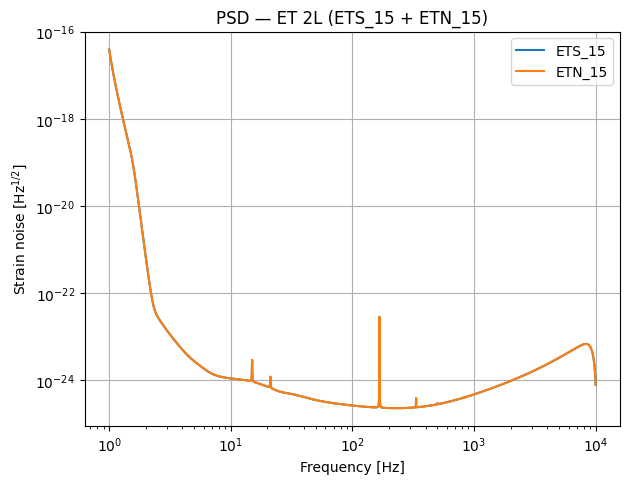

Network initialised with detectors: ['ETS_15', 'ETN_15']


In [4]:
import re, tempfile

# ---------- Detector configuration ----------
# Source YAML (contains bare PSD filenames like "ET_15_coba.txt")
yaml_template = Path("configs/coba.yaml")

# Directory containing the local PSD files
psd_dir = Path("psds").resolve()

def resolve_psd_paths(yaml_path, psd_dir):
    """Read a GWFish config YAML and resolve every bare `psd_data` filename
    to an absolute path under *psd_dir*. Returns the path to a temporary
    YAML file with all paths resolved. Makes it safe to pass to GWFish."""
    text = yaml_path.read_text()
    # Match `psd_data:` followed by a value that is NOT already an absolute path
    def _resolve(m):
        fname = m.group(1).strip()
        if fname.startswith("/"):        # already absolute → keep as-is
            return m.group(0)
        resolved = (psd_dir / fname).resolve()
        if not resolved.exists():
            raise FileNotFoundError(
                f"PSD file not found: {resolved}  (referenced in {yaml_path})"
            )
        return f"psd_data:{m.group(0).split('psd_data:')[1].replace(fname, str(resolved))}"
    resolved_text = re.sub(r"psd_data:\s*(.+)", _resolve, text)
    # Write to a temp file that GWFish can read
    tmp = tempfile.NamedTemporaryFile(
        mode="w", suffix=".yaml", prefix="gwfish_conf_", delete=False
    )
    tmp.write(resolved_text)
    tmp.flush()
    return Path(tmp.name)

conf_file = resolve_psd_paths(yaml_template, psd_dir)
print(f"Resolved config written to: {conf_file}")

# Network: ET 2L (South + North, 15 km arms)
detector_names = ["ETS_15", "ETN_15"]

waveform_model = "IMRPhenomD_NRTidalv2"

network = gw.detection.Network(
    detector_ids  = detector_names,
    config        = conf_file,
    detection_SNR = (0, 8),
)

# Quick sanity check: plot the PSDs
for det in network.detectors:
    det.components[0].plot_psd()
plt.legend(detector_names)
plt.title("PSD — ET 2L (ETS_15 + ETN_15)")
plt.savefig(output_dir / "PSDs.pdf")
plt.show()
print(f"Network initialised with detectors: {detector_names}")

## 4. Compute Network SNR (Multiprocessing)

We compute the SNR for every event using `gw.utilities.get_snr`, split across all available CPU cores.
The last column of the returned array is the **network (quadrature-summed) SNR**.

In [5]:
from joblib import Parallel, delayed

my_pop_split = np.array_split(df_params, cpus)

def run_snr(chunk_df):
    return gw.utilities.get_snr(chunk_df, network=network, waveform_model=waveform_model)

snr_chunks = Parallel(n_jobs=cpus, verbose=10)(
    delayed(run_snr)(chunk) for chunk in my_pop_split
)

snr_array = np.concatenate(snr_chunks)   # shape: (n_ev, n_detectors + 1)

# Individual detector SNRs and network SNR
individual_snrs = snr_array[:, :-1]
network_snr     = snr_array[:, -1]

print(f"SNR computed for {len(network_snr)} events")
print(f"  Median network SNR : {np.median(network_snr):.1f}")
print(f"  Max    network SNR : {np.max(network_snr):.1f}")

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:   20.8s remaining:   48.5s
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:   20.8s remaining:   20.8s
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:   20.9s remaining:    8.9s


SNR computed for 786 events
  Median network SNR : 10.2
  Max    network SNR : 112.6


[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   22.0s finished


### Fallback: Single-Process SNR Computation

If multiprocessing causes issues (e.g., on some systems or inside containers), uncomment and run
the cell below **instead** of the multiprocessing cell above.

In [6]:
# # --- Single-process fallback (uncomment if multiprocessing fails) ---
# snr_array   = gw.utilities.get_snr(df_params, network=network, waveform_model=waveform_model)
#
# individual_snrs = np.array(snr_array)[:, :-1]
# network_snr     = np.array(snr_array)[:, -1]
#
# print(f"SNR computed for {len(network_snr)} events (single process)")
# print(f"  Median network SNR : {np.median(network_snr):.1f}")
# print(f"  Max    network SNR : {np.max(network_snr):.1f}")

## 5. Detection Rate & Redshift Distribution

Apply an SNR threshold of 8 and compute the detection fraction with Poisson uncertainty.

['ETS_15', 'ETN_15'] detected 544 / 786  (SNR > 8.0)
Detection rate: 0.692  [0.662, 0.722]


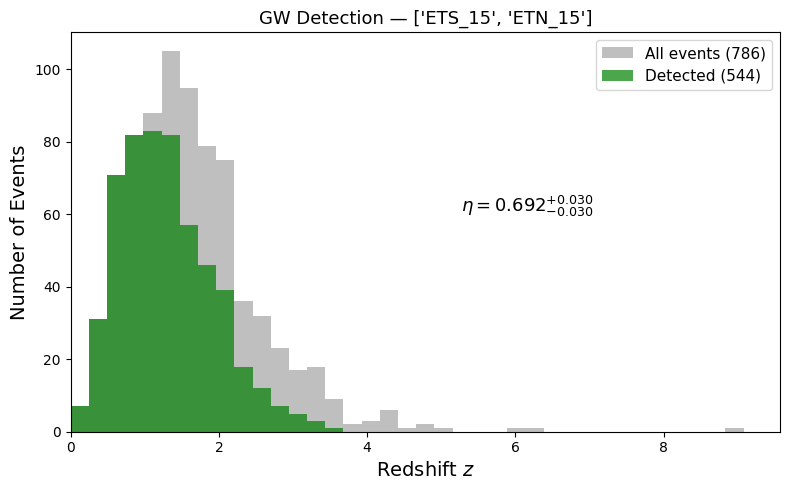

In [7]:
SNR_THRESHOLD = 8.0

detected_mask   = network_snr > SNR_THRESHOLD
total_events    = len(network_snr)
detected_events = int(np.sum(detected_mask))

# Poisson uncertainty on the detection count
poisson_err = np.sqrt(detected_events)
ratio       = detected_events / total_events
ratio_plus  = (detected_events + poisson_err) / total_events
ratio_minus = (detected_events - poisson_err) / total_events

print(f"{detector_names} detected {detected_events} / {total_events}  (SNR > {SNR_THRESHOLD})")
print(f"Detection rate: {ratio:.3f}  [{ratio_minus:.3f}, {ratio_plus:.3f}]")

# ---- Redshift histogram ----
bins = np.linspace(0, redshift.max() + 0.5, 40)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(redshift, bins=bins, color="gray", alpha=0.5,
        label=f"All events ({total_events})")
ax.hist(redshift[detected_mask], bins=bins, color="green", alpha=0.7,
        label=f"Detected ({detected_events})")
ax.text(
    0.55, 0.55,
    f"$\\eta = {{{ratio:.3f}}}^{{+{ratio_plus - ratio:.3f}}}_{{-{ratio - ratio_minus:.3f}}}$",
    transform=ax.transAxes, fontsize=13,
)
ax.set_xlabel("Redshift $z$", fontsize=14)
ax.set_ylabel("Number of Events", fontsize=14)
ax.set_title(f"GW Detection — {detector_names}", fontsize=13)
ax.set_xlim(0, redshift.max() + 0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(output_dir / "detection_redshift_hist.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6. Save Results

Save the full catalogue augmented with the network SNR and the detection mask
so it can be used downstream (e.g., for joint GW+GRB population studies).

In [8]:
# Augment the original catalogue with SNR info
results_df = grb_cat.copy()
for i, det_name in enumerate(detector_names):
    results_df[f"snr_{det_name}"] = individual_snrs[:, i]
results_df["snr_network"] = network_snr
results_df["detected"]    = detected_mask

# Save
results_df.to_csv(output_dir / "catalogue_with_snr.csv", index=False)

print(f"Saved augmented catalogue to {output_dir / 'catalogue_with_snr.csv'}")
print(f"Columns: {list(results_df.columns)}")
results_df.head()

Saved augmented catalogue to Output_files/tutorial3_gwfish/catalogue_with_snr.csv
Columns: ['z', 'theta_v', 'Ep_obs', 'Fp', 'T90', 'snr_ETS_15', 'snr_ETN_15', 'snr_network', 'detected']


,z,theta_v,Ep_obs,Fp,T90,snr_ETS_15,snr_ETN_15,snr_network,detected
0,1.705149,4.240475,102.828609,12.300127,0.173366,5.146161,2.792168,5.854842,False
1,2.771388,2.510711,443.653914,2.522608,0.380590,4.876034,4.208063,6.440769,False
2,1.317878,3.876423,367.807670,1.098280,0.729378,5.605680,6.964115,8.939941,True
3,4.697218,2.680669,470.579397,0.692514,1.494197,3.611508,2.794524,4.566438,False
4,2.110449,5.034925,78.695918,3.045865,0.119049,2.171397,5.443914,5.860987,False


---

## Exercise: Add Cosmic Explorer to the Network

Now it's your turn! Re-run the detection analysis with an **expanded network** that includes
`CE40` (Cosmic Explorer, 40 km arms) alongside the two ET detectors.

**Steps:**
1. Inspect the available detectors in the configuration file (printed below).
2. Define a new `detector_names` list that includes `CE40`.
3. Build a new `Network`, compute SNRs, and compare the detection rate to the ET-only result.

**Hint:** You only need to change `detector_names` and re-run the SNR computation.

In [9]:
# Print all available detector entries from the configuration YAML
print("Available detectors in coba.yaml:")
print("=" * 40)
with open(yaml_template) as f:
    for line in f:
        # Print top-level detector names (no leading whitespace, ending with ':')
        stripped = line.rstrip()
        if stripped and not stripped.startswith(" ") and not stripped.startswith("#") and stripped.endswith(":"):
            print(f"  • {stripped[:-1]}")

Available detectors in coba.yaml:
  • ET
  • ETS_15
  • ETN_15
  • CE40
  • CE20


In [10]:
# ============================================================
# EXERCISE: Define the extended network and compute SNRs
# ============================================================

# TODO: Add CE40 to the detector list
detector_names_ext = ["ETS_15", "ETN_15"]  # <-- modify this line!

network_ext = gw.detection.Network(
    detector_ids  = detector_names_ext,
    config        = conf_file,
    detection_SNR = (0, 8),
)

# Compute SNR (single-process for simplicity; swap for joblib version if you prefer)
snr_array_ext   = gw.utilities.get_snr(df_params, network=network_ext, waveform_model=waveform_model)
network_snr_ext = np.array(snr_array_ext)[:, -1]

detected_ext = int(np.sum(network_snr_ext > SNR_THRESHOLD))
ratio_ext    = detected_ext / total_events

print(f"Extended network: {detector_names_ext}")
print(f"  Detected {detected_ext} / {total_events}  (SNR > {SNR_THRESHOLD})")
print(f"  Detection rate: {ratio_ext:.3f}")
print(f"\nOriginal ET-only rate: {ratio:.3f}")
print(f"Improvement factor:   {ratio_ext / ratio:.2f}x" if ratio > 0 else "")

Extended network: ['ETS_15', 'ETN_15']
  Detected 544 / 786  (SNR > 8.0)
  Detection rate: 0.692

Original ET-only rate: 0.692
Improvement factor:   1.00x


---

## Summary

In this notebook we:

1. Loaded the GRB catalogue from Tutorial 2 (redshift + viewing angle for each event)
2. Generated BNS merger parameters for every event (Gaussian masses, randomised extrinsic params)
3. Computed the **network SNR** for the **ET 2L** detector configuration using GWFish (multiprocessing)
4. Derived the GW detection rate with Poisson uncertainties
5. Saved the augmented catalogue (per-detector SNR, network SNR, detection flag)

**Exercise:** Extended the network with `CE40` and compared detection rates.